<a href="https://colab.research.google.com/github/dkhan1209/Face-Recognition/blob/main/VietnamseseDishesRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import load_img
train_dir = '/content/drive/MyDrive/Du_An_Mon_An'
img_width, img_height = 280, 280
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 118 images belonging to 5 classes.


In [5]:
model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 280, 280, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 140, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 138, 138, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 304704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    39,002,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,022,277 (148.86 MB)

 Trainable params: 39,022,277 (148.86 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:

model.fit(train_generator, epochs=25)
model.save('model_mon_an.h5')
print("Đã huấn luyện và lưu mô hình thành công!")

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.2119 - loss: 26.7622
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 574ms/step - accuracy: 0.1695 - loss: 8.4326
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 651ms/step - accuracy: 0.2458 - loss: 1.9704
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 560ms/step - accuracy: 0.2288 - loss: 1.6212
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - accuracy: 0.2034 - loss: 1.6012
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 568ms/step - accuracy: 0.2797 - loss: 1.5619
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 623ms/step - accuracy: 0.2119 - loss: 1.5765
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 932ms/step - accuracy: 0.2288 - loss: 1.5619
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 646ms/step - accuracy: 0.2542 - loss: 1.5524
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 638ms/step - accuracy: 0.3051 - loss: 1.4972
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 555ms/step - accuracy: 0.2034 - loss: 1.5666
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 671ms/step - accuracy: 0.3220 - lo

Đã huấn luyện và lưu mô hình thành công!


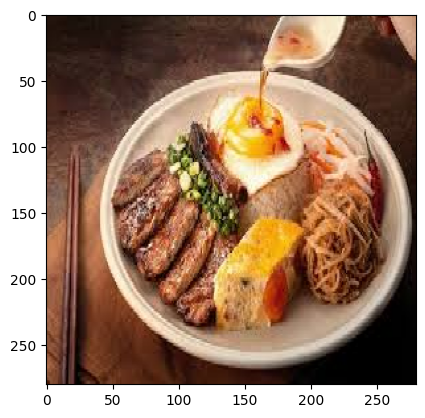

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
Kết quả dự đoán: Món này có vẻ là COM_TAM


In [10]:

mymodel = load_model('model_mon_an.h5')
path = '/content/drive/MyDrive/Du_An_Mon_An/com_tam/download (3).jpg'
img = load_img(path, target_size=(280, 280))
plt.imshow(img)
plt.show()
img = np.array(img) / 255.0
img = img.reshape(1, img_width, img_height, 3)
prediction = np.argmax(mymodel.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
mon_an_du_doan = class_labels[prediction]

print(f'Kết quả dự đoán: Món này có vẻ là {mon_an_du_doan.upper()}')